# 04 — Custom CNN — Build & Train
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Build a 3-block custom CNN from scratch
- Train with augmented data and callbacks
- Plot training curves (accuracy & loss)
- Save the best model checkpoint

**Prerequisite**: Run notebooks 02 and 03 first to generate `data/*.npy` files.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.config import DATA_DIR, IMG_SIZE, BATCH_SIZE, EPOCHS, CUSTOM_CNN_CHECKPOINT
from src.data_loader import build_augmentation_generator
from src.models import build_custom_cnn, get_callbacks

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

2026-02-28 01:51:26.760711: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 01:51:27.216080: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 01:51:36.662459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.20.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Split Arrays

In [2]:
X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(DATA_DIR, "y_val.npy"))

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")

Train : (31367, 64, 64, 3)
Val   : (7842, 64, 64, 3)


## 2. Build Model

In [3]:
model = build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3))
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

/mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772239938.375240    1367 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,629,067 (17.66 MB)

 Trainable params: 4,626,635 (17.65 MB)

 Non-trainable params: 2,432 (9.50 KB)


Total parameters: 4,629,067


## 3. Setup Augmentation & Callbacks

In [4]:
datagen = build_augmentation_generator()
datagen.fit(X_train)

callbacks = get_callbacks(CUSTOM_CNN_CHECKPOINT)
print("Ready to train.")

Ready to train.


## 4. Train

In [5]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
print("\nTraining complete.")

Epoch 1/40


2026-02-28 01:52:36.007598: I external/local_xla/xla/service/service.cc:163] XLA service 0x7bd698020800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-28 01:52:36.007630: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2026-02-28 01:52:36.148959: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-28 01:52:36.804647: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-28 01:52:37.174173: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-28 01:52:37.174382: I e

  1/491 ━━━━━━━━━━━━━━━━━━━━ 2:04:35 15s/step - accuracy: 0.0156 - loss: 5.3512

I0000 00:00:1772239968.030729    1457 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3678 - loss: 2.5683

2026-02-28 01:53:15.503165: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-28 01:53:16.033897: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_237', 60 bytes spill stores, 60 bytes spill loads

2026-02-28 01:53:16.604383: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_259', 288 bytes spill stores, 288 bytes spill loads

2026-02-28 01:53:16.784584: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_259', 8 byte


Epoch 1: val_accuracy improved from None to 0.89237, saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_custom_cnn.keras

Epoch 1: finished saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_custom_cnn.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.5541 - loss: 1.6176 - val_accuracy: 0.8924 - val_loss: 0.3464 - learning_rate: 0.0010
Epoch 2/40
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8379 - loss: 0.5320
Epoch 2: val_accuracy did not improve from 0.89237
491/491 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8632 - loss: 0.4492 - val_accuracy: 0.8284 - val_loss: 0.5777 - learning_rate: 0.0010
Epoch 3/40
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9047 - loss: 0.3129
Epoch 3: val_accuracy improved from 0.89237 to 0.94109, saving model to /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/best_custom_cnn.keras

Ep

## 5. Training Curves

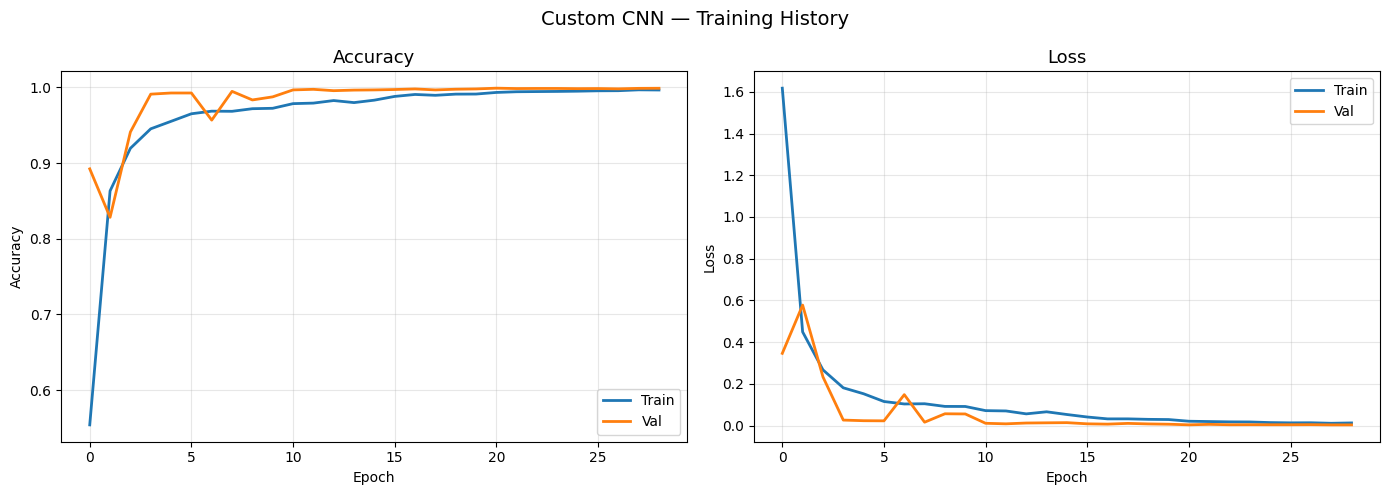

Best validation accuracy: 0.9990 (99.90%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Custom CNN — Training History', fontsize=14)
plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

## 6. Save Final Model

In [7]:
from src.config import CUSTOM_CNN_FINAL
model.save(CUSTOM_CNN_FINAL)
print(f"Final model saved → {CUSTOM_CNN_FINAL}")

Final model saved → /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_8_Traffic_Sign_Recognition/models/custom_cnn_final.keras
